# **Introduction**

These are some examples we discussed in class. Try to solve them before looking at the answers. I use the following code to import my dataset.

In [1]:
# Helpful documentation to pandas: https://pandas.pydata.org/pandas-docs/stable/index.html
import pandas as pd
data = pd.read_csv('SweetFaceNobel.txt',sep=',')

country = data['COUNTRY']
numNP = data['NOBEL']
amtch = data['CHOC']
pop = data['POP']

/Users/bobs/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/bobs/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


# 1.1 Regression

Make a scatter plot of the number of Nobel prizes to chocolate consumption per capita, and another scatter plot of the number of Nobel prizes *per capita* to chocolate consumption per capita.

#### Answer

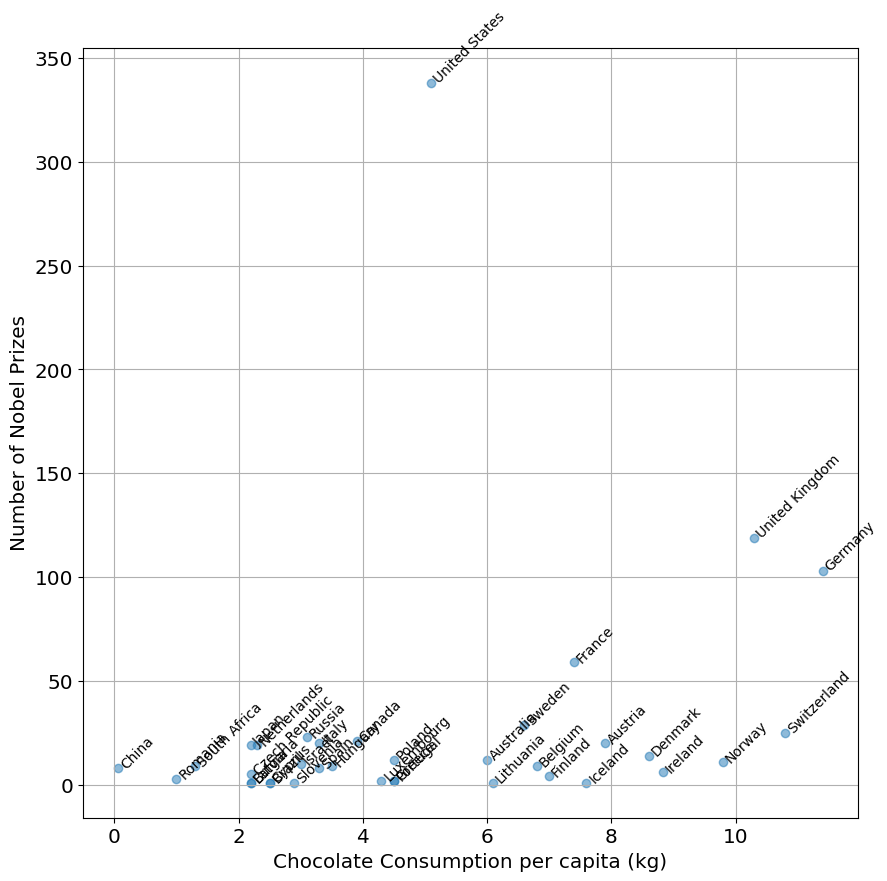

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# The following makes the plot look nice
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (10, 10),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
plt.rcParams.update(params)

fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(amtch,numNP,alpha=0.5)
for ii in range(len(country)):
  ax.text(amtch[ii],numNP[ii],country[ii],{'rotation':45})

plt.xlabel('Chocolate Consumption per capita (kg)')
plt.ylabel('Number of Nobel Prizes')
plt.grid()
plt.show()

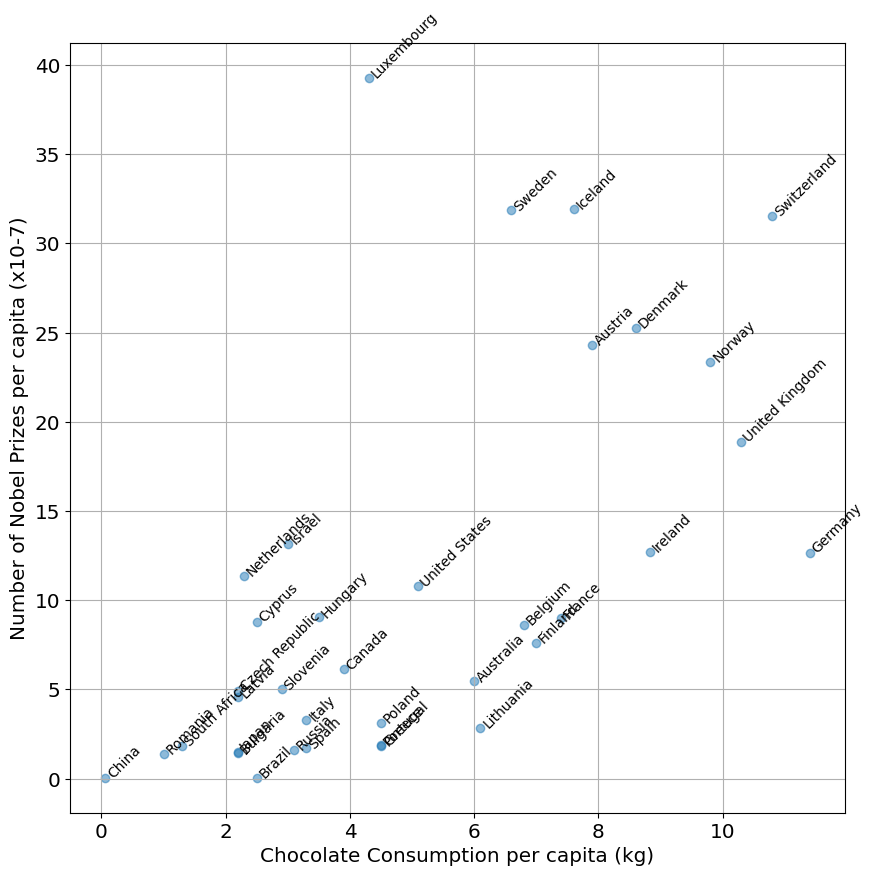

In [3]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(amtch,10000000*numNP/pop,alpha=0.5)
for ii in range(len(country)):
  ax.text(amtch[ii],10000000*numNP[ii]/pop[ii],country[ii],{'rotation':45})

plt.xlabel('Chocolate Consumption per capita (kg)')
plt.ylabel('Number of Nobel Prizes per capita (x10-7)')
plt.grid()
plt.show()

# 1.2

Now fit a line by least squares regression to relate the Nobel prize per capita to the chocolate consumption per capita, and draw that on the scatter plot.

#### Answer

Coefficients are -0.40384565722084 [2.19089071]
Coefficients are [-0.40384566  2.19089071]


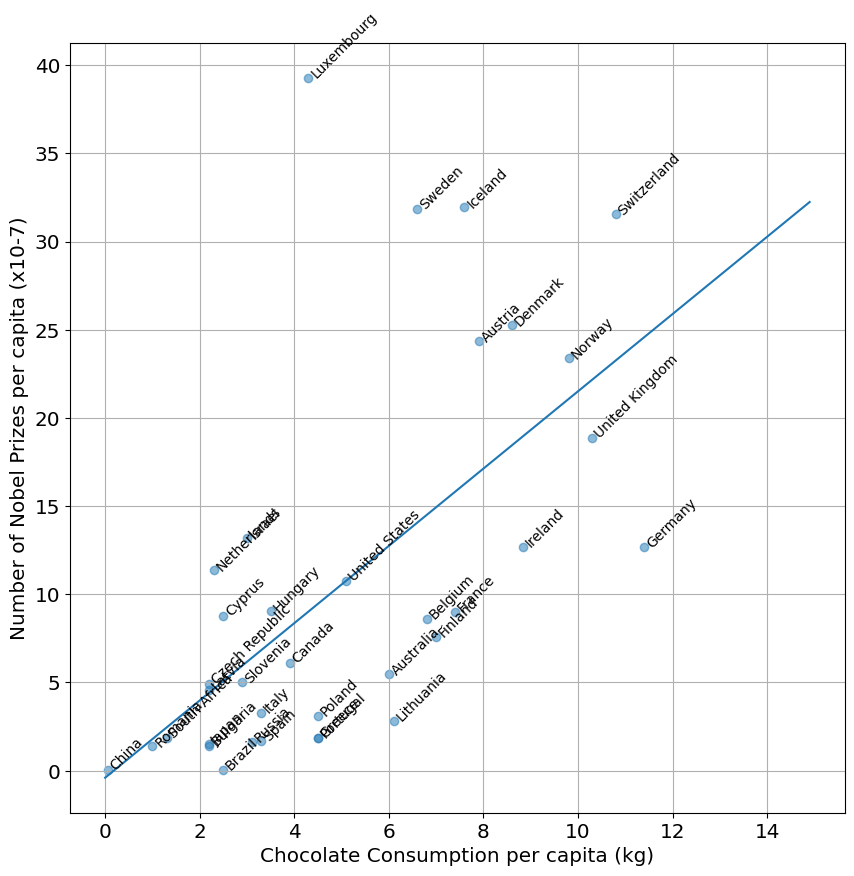

In [4]:
# here's the short way
from sklearn.linear_model import LinearRegression
LR = LinearRegression() 
H = np.vstack(amtch.values)
reg = LR.fit(H, 10000000*numNP/pop)
print('Coefficients are', reg.intercept_, reg.coef_)

# here's the long way
H = np.vstack((np.ones(amtch.shape),amtch)).T # the ones included for intercept
HTH = np.matmul(H.T,H)
HTHinv = np.linalg.inv(HTH)
HTHinvHT = np.matmul(HTHinv,H.T)
w = np.dot(HTHinvHT,10000000*numNP/pop)
print('Coefficients are', w)

z = np.arange(0,15,0.1)
H = np.vstack((np.ones(z.shape),z)).T
y = np.matmul(H,w)

fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(amtch,10000000*numNP/pop,alpha=0.5)
for ii in range(len(country)):
  ax.text(amtch[ii],10000000*numNP[ii]/pop[ii],country[ii],{'rotation':45})

plt.plot(z,y)
plt.xlabel('Chocolate Consumption per capita (kg)')
plt.ylabel('Number of Nobel Prizes per capita (x10-7)')
plt.grid()
plt.show()

Coefficients are -0.40384565722084 [2.19089071]


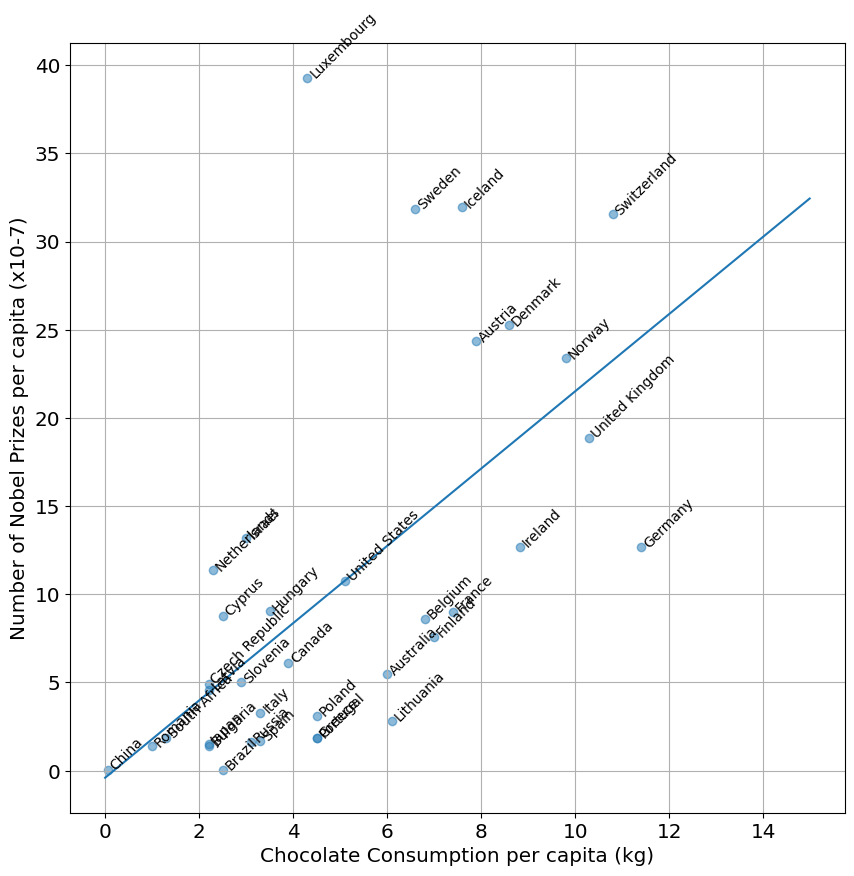

In [5]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression() # default includes intercept

LR.fit(np.array(amtch).reshape(-1, 1),10000000*numNP/pop)

print('Coefficients are', LR.intercept_, LR.coef_)

fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(amtch,10000000*numNP/pop,alpha=0.5)
for ii in range(len(country)):
  ax.text(amtch[ii],10000000*numNP[ii]/pop[ii],country[ii],{'rotation':45})

x = np.arange(0,15,0.01)
plt.plot(x,LR.predict(x.reshape(-1, 1)))
plt.xlabel('Chocolate Consumption per capita (kg)')
plt.ylabel('Number of Nobel Prizes per capita (x10-7)')
plt.grid()
plt.show()

# 1.3

Now fit a polynomial of degree two by least squares regression to relate the Nobel prize per capita to the chocolate consumption per capita, and draw that on the scatter plot.

#### Answer

Coefficients are [-1.82347145  2.87396862 -0.05914138]


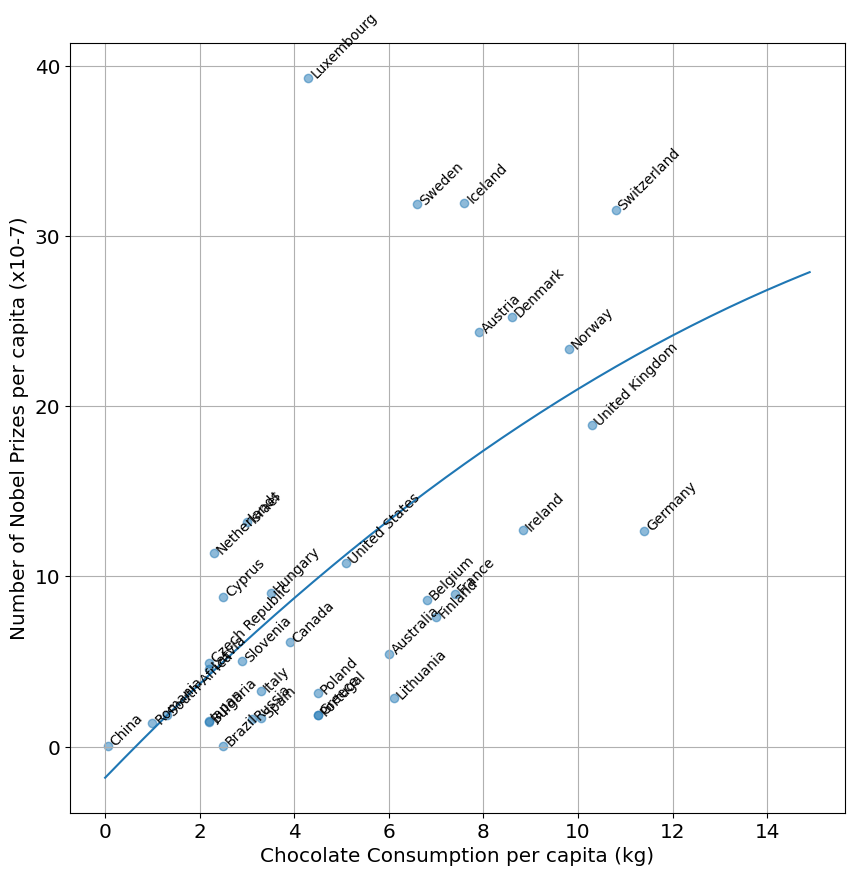

In [6]:
H = np.vstack((np.ones(amtch.shape),amtch,amtch**2)).T
HTH = np.matmul(H.T,H)
HTHinv = np.linalg.inv(HTH)
HTHinvHT = np.matmul(HTHinv,H.T)
w = np.dot(HTHinvHT,10000000*numNP/pop)
print('Coefficients are', w)

z = np.arange(0,15,0.1)
H = np.vstack((np.ones(z.shape),z,z**2)).T
y = np.matmul(H,w)

fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(amtch,10000000*numNP/pop,alpha=0.5)
for ii in range(len(country)):
  ax.text(amtch[ii],10000000*numNP[ii]/pop[ii],country[ii],{'rotation':45})

plt.plot(z,y)
plt.xlabel('Chocolate Consumption per capita (kg)')
plt.ylabel('Number of Nobel Prizes per capita (x10-7)')
plt.grid()
plt.show()

Coefficients are -1.8234714545633217 [ 2.87396862 -0.05914138]


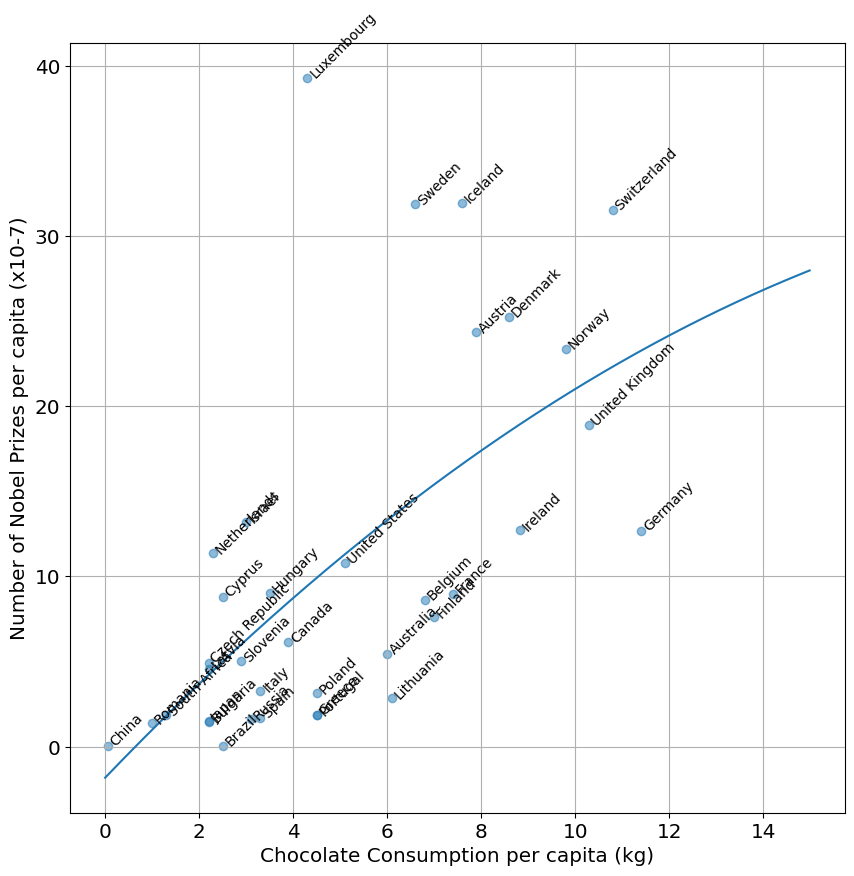

In [7]:
H = np.vstack((amtch,amtch**2))
LR = LinearRegression() # default includes intercept
LR.fit(H.T,10000000*numNP/pop)
print('Coefficients are', LR.intercept_, LR.coef_)

fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(amtch,10000000*numNP/pop,alpha=0.5)
for ii in range(len(country)):
  ax.text(amtch[ii],10000000*numNP[ii]/pop[ii],country[ii],{'rotation':45})

x = np.arange(0,15,0.01)
H = np.vstack((x,x**2))

plt.plot(x,LR.predict(H.T))
plt.xlabel('Chocolate Consumption per capita (kg)')
plt.ylabel('Number of Nobel Prizes per capita (x10-7)')
plt.grid()
plt.show()

# 1.4

Now fit a polynomial of degree 10 by least squares regression to relate the Nobel prize per capita to the chocolate consumption per capita, and draw that on the scatter plot.

#### Answer

Coefficients are [ 4.62911068e+00 -9.68080576e+01  2.16471474e+02 -1.97627562e+02
  9.65256702e+01 -2.78964330e+01  4.98428572e+00 -5.54927779e-01
  3.73938464e-02 -1.39243559e-03  2.19392819e-05]


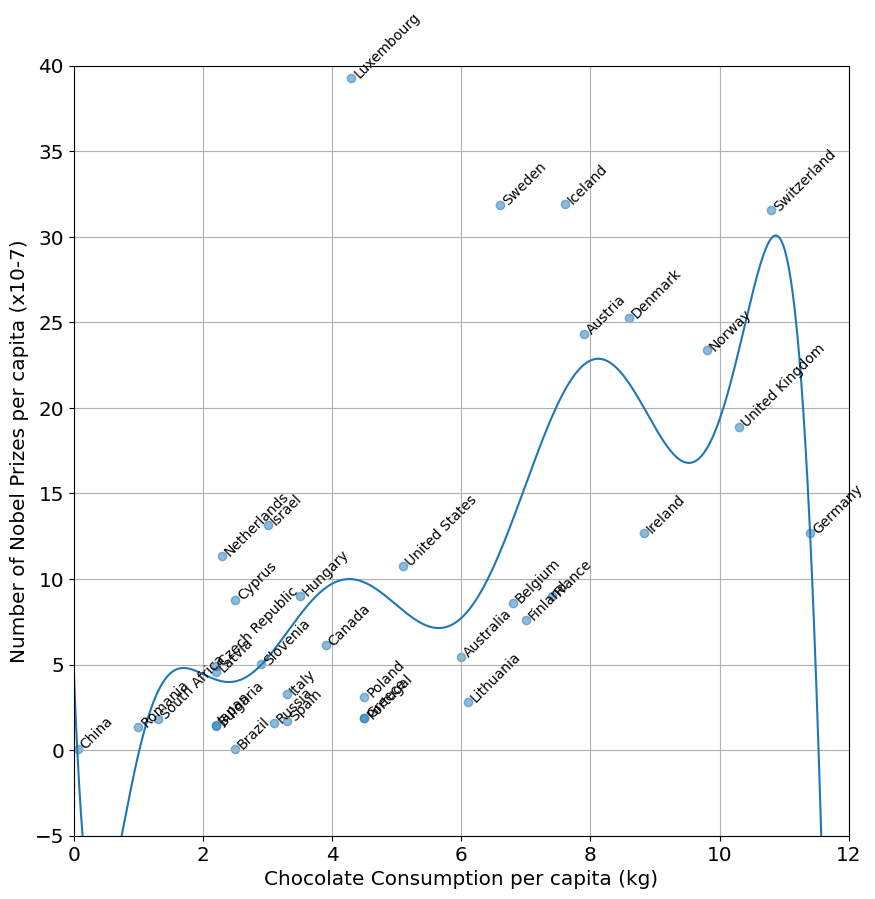

In [8]:
degree = 10

z = np.arange(0,14,0.002)
Hz = np.ones(z.shape)
H = np.ones(amtch.shape)
for dd in range(1,degree+1):
  H = np.vstack((H,amtch**dd))
  Hz = np.vstack((Hz,z**dd))

H = H.T
Hz = Hz.T
HTH = np.matmul(H.T,H)
HTHinv = np.linalg.inv(HTH)
HTHinvHT = np.matmul(HTHinv,H.T)
w = np.matmul(HTHinvHT,10000000*numNP/pop)
print('Coefficients are', w)

y = np.matmul(Hz,w)

fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(amtch,10000000*numNP/pop,alpha=0.5)
for ii in range(len(country)):
  ax.text(amtch[ii],10000000*numNP[ii]/pop[ii],country[ii],{'rotation':45})

plt.plot(z,y)
plt.xlabel('Chocolate Consumption per capita (kg)')
plt.ylabel('Number of Nobel Prizes per capita (x10-7)')
plt.xlim((0,12))
plt.ylim((-5,40))
plt.grid()
plt.show()